# Multivariate Statistical Arbitrage Pipeline

End-to-end notebook: Configuration → Data → PCA → Johansen → Spreads → Backtest → Walk-Forward → Dashboards

---
## 1. Configuration
Select sector, tickers, and date range. Override defaults as needed.

In [1]:
import sys
sys.path.insert(0, '..')

from src import config, data_loader, features, models, backtest, utils, dashboard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# ── Execution Mode ──
# "ideal"     → zero friction (no costs, no borrow fees, no stop-loss, no drawdown limit)
# "realistic" → production-grade costs and risk limits
EXECUTION_MODE = 'ideal'
config.apply_mode(EXECUTION_MODE)

# ── Override defaults here ──
SECTOR = 'tech' #config.DEFAULT_SECTOR        # e.g. 'tech', 'energy', 'semiconductors'
TICKERS = None                         # None = use sector default, or ['AAPL', 'MSFT', ...]
START_DATE = config.DEFAULT_START_DATE  # '2024-03-01'
END_DATE = config.DEFAULT_END_DATE     # '2025-12-31'

print(f'=== Execution Mode: {config.EXECUTION_MODE.upper()} ===')
print(f'  Transaction Cost: {config.TRANSACTION_COST_BPS} bps')
print(f'  Short Borrow Rate: {config.SHORT_BORROW_RATE}')
print(f'  Stop Loss: {config.STOP_LOSS}')
print(f'  Drawdown Limit: {config.DRAWDOWN_LIMIT}')
print()
print(f'Sector: {SECTOR}')
print(f'Tickers: {TICKERS or config.TICKER_UNIVERSES[SECTOR]}')
print(f'Window: {START_DATE} → {END_DATE}')

=== Execution Mode: IDEAL ===
  Transaction Cost: 0.0 bps
  Short Borrow Rate: 0.0
  Stop Loss: 1.0
  Drawdown Limit: 1.0

Sector: tech
Tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA', 'TSM', 'AVGO', 'ORCL', 'CRM', 'CSCO', 'ADBE']
Window: 2013-01-01 → 2018-12-31


---
## 2. Data Loading
Fetch adjusted close prices via yfinance (cached locally).

In [2]:
prices = data_loader.load_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    sector=SECTOR,
)

print(f'Shape: {prices.shape}')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Missing values:\n{prices.isnull().sum()}')
prices.head()

Shape: (1509, 12)
Date range: 2013-01-02 → 2018-12-28
Missing values:
Ticker
AAPL    0
ADBE    0
AMZN    0
AVGO    0
CRM     0
CSCO    0
GOOG    0
META    0
MSFT    0
NVDA    0
ORCL    0
TSM     0
dtype: int64


Ticker,AAPL,ADBE,AMZN,AVGO,CRM,CSCO,GOOG,META,MSFT,NVDA,ORCL,TSM
Date,,,,,,,,,,,,
2013-01-02,16.596684,38.340000,12.8655,2.367877,42.278797,13.667672,17.879629,27.805767,22.242884,0.293434,28.763950,12.855550
2013-01-03,16.387190,37.750000,12.9240,2.380248,41.671188,13.741589,17.890013,27.577362,21.944916,0.293665,28.448858,12.848452
2013-01-04,15.930732,38.130001,12.9575,2.364966,41.893482,13.761753,18.243526,28.560493,21.534197,0.303354,28.697617,12.756120
2013-01-07,15.837021,37.939999,13.4230,2.351869,41.737869,13.634073,18.163925,29.215919,21.493935,0.294588,28.548376,12.571455
2013-01-08,15.879638,38.139999,13.3190,2.335859,41.982403,13.647513,18.128078,28.858416,21.381191,0.288128,28.556646,12.457812


---
## 3. PCA Analysis
Eigenportfolio decomposition, variance explained, and persistence.

In [3]:
returns = features.compute_returns(prices)

# PCA decomposition
pca_result = features.run_pca(returns, n_components=config.N_COMPONENTS)

print('Explained Variance Ratio:')
for i, ev in enumerate(pca_result['explained_variance_ratio']):
    print(f'  PC{i+1}: {ev:.4f} ({ev*100:.1f}%)')
print(f'  Total: {sum(pca_result["explained_variance_ratio"]):.4f}')

# Eigenportfolio weights
weight_df = pd.DataFrame(
    pca_result['components'],
    columns=prices.columns,
    index=[f'PC{i+1}' for i in range(config.N_COMPONENTS)],
)
print('\nEigenportfolio Weights (sparse):')
weight_df.round(4)

Explained Variance Ratio:
  PC1: 0.4601 (46.0%)
  PC2: 0.1000 (10.0%)
  PC3: 0.0780 (7.8%)
  PC4: 0.0699 (7.0%)
  PC5: 0.0585 (5.9%)
  Total: 0.7665

Eigenportfolio Weights (sparse):


Ticker,AAPL,ADBE,AMZN,AVGO,CRM,CSCO,GOOG,META,MSFT,NVDA,ORCL,TSM
PC1,0.0671,0.0878,0.0960,0.0983,0.1019,0.0621,0.0759,0.0967,0.0752,0.1202,0.0556,0.0632
PC2,0.0000,-0.0330,-0.1439,0.0976,-0.0614,0.0236,-0.0701,-0.2187,0.0000,0.2963,0.0000,0.0554
PC3,0.1095,0.0000,-0.0698,0.2598,0.0000,0.0614,0.0000,-0.1096,0.0208,-0.2266,0.0656,0.0768
PC4,0.0186,-0.1161,-0.0488,0.1608,-0.1120,-0.0771,-0.0263,0.2257,-0.0872,0.0508,-0.0766,0.0000
PC5,-0.1119,0.0624,-0.1816,0.0509,0.2840,0.0000,-0.0908,0.0546,-0.0727,0.0000,0.0000,-0.0912


---
## 4. Johansen Cointegration
Test for multivariate cointegrating relationships and extract weight vectors.

In [4]:
# Johansen test
joh = models.johansen_test(prices)
rank = models.johansen_rank(joh)

print(f'Cointegration Rank: {rank}')
print(f'  → {rank} independent mean-reverting relationships found\n')

# Trace statistics
trace_df = models.johansen_trace_statistic(joh)
print('Trace Test Results:')
display(trace_df)

# Select significant vectors
weight_vectors = models.select_vectors(joh)
print(f'\nSelected {weight_vectors.shape[0]} weight vector(s)')

if weight_vectors.size > 0:
    vec_df = pd.DataFrame(weight_vectors, columns=prices.columns,
                          index=[f'Vector {i+1}' for i in range(weight_vectors.shape[0])])
    display(vec_df.round(4))

Cointegration Rank: 2
  → 2 independent mean-reverting relationships found

Trace Test Results:


,trace_stat,cv_90,cv_95,cv_99,significant_95
r<=0,366.468391,326.5354,334.9795,351.2150,True
r<=1,294.446987,277.3740,285.1402,300.2821,True
r<=2,236.995782,232.1030,239.2468,253.2526,False
r<=3,180.403322,190.8714,197.3772,210.0366,False
r<=4,130.961165,153.6341,159.5290,171.0905,False
r<=5,94.857374,120.3673,125.6185,135.9825,False
r<=6,65.660708,91.1090,95.7542,104.9637,False
r<=7,43.644729,65.8202,69.8189,77.8202,False
r<=8,28.407553,44.4929,47.8545,54.6815,False
r<=9,14.157709,27.0669,29.7961,35.4628,False



Selected 2 weight vector(s)


Ticker,AAPL,ADBE,AMZN,AVGO,CRM,CSCO,GOOG,META,MSFT,NVDA,ORCL,TSM
Vector 1,0.1295,0.0542,0.0149,-0.7323,0.0045,-0.3495,-0.1429,0.0694,-0.1133,-1.1057,-0.2268,0.7671
Vector 2,0.1431,0.1160,0.0758,0.3973,-0.0844,-0.6508,-0.2251,-0.0363,0.0108,-1.7063,-0.2244,0.2889


---
## 5. Spread Construction & Z-Scores
Build multi-leg spreads and compute rolling z-scores.

Constructed 2 spread(s)

Spread 1 Diagnostics:
  Half-Life:        194.2 days
  Hurst Exponent:   1.0017 (Trending)
  Zero-Crossing:    0.0816
  Variance Ratios:  {1: np.float64(0.9999999999901423), 5: np.float64(0.9272049153211228), 10: np.float64(0.868752900037324), 20: np.float64(0.7617876683678783)}


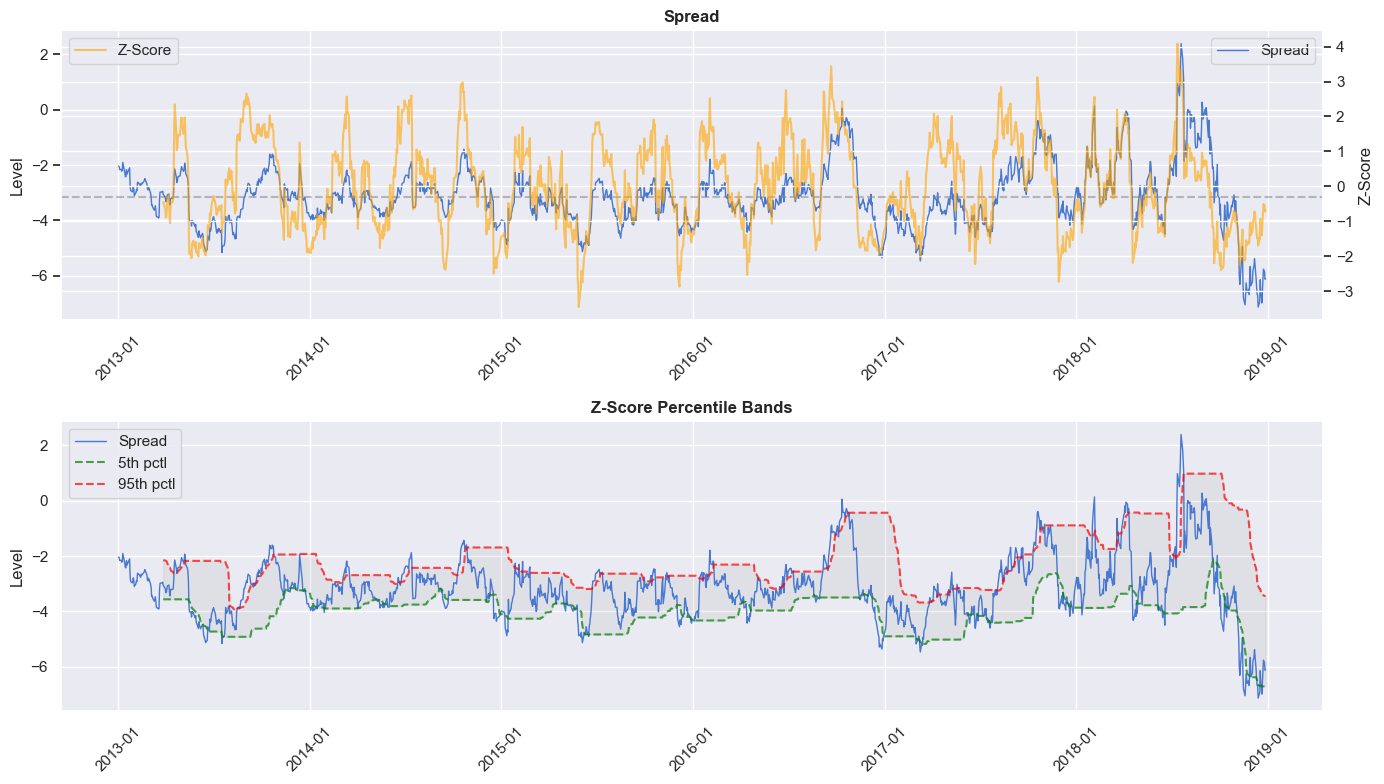

In [5]:
if weight_vectors.size > 0:
    # Construct spreads
    spreads = features.construct_spreads(prices, weight_vectors)
    print(f'Constructed {spreads.shape[1]} spread(s)\n')
    
    # Z-scores for first spread
    spread_1 = spreads.iloc[:, 0]
    zscore_1 = features.compute_zscore(spread_1)
    bands_1 = features.zscore_percentile_bands(spread_1)
    
    # Mean reversion diagnostics
    hl = features.ou_half_life(spread_1)
    h = features.hurst_exponent(spread_1)
    vr = features.variance_ratio_test(spread_1)
    zcr = features.zero_crossing_rate(spread_1)
    
    print(f'Spread 1 Diagnostics:')
    print(f'  Half-Life:        {hl:.1f} days')
    print(f'  Hurst Exponent:   {h:.4f} ({"Mean-Reverting" if h < 0.5 else "Trending"})')
    print(f'  Zero-Crossing:    {zcr:.4f}')
    print(f'  Variance Ratios:  {vr}')
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    utils.plot_spread(spread_1, zscore_1, ax=axes[0])
    utils.plot_zscore_bands(spread_1, bands_1, ax=axes[1])
    plt.tight_layout()
    plt.show()
else:
    print('No cointegration found. Cannot construct spreads.')

---
## 6. Signal Generation & Backtest
Run single-pass backtest with full parameters.

Final Equity: $1,098,801.61
Return: 9.88%
Trades: 682


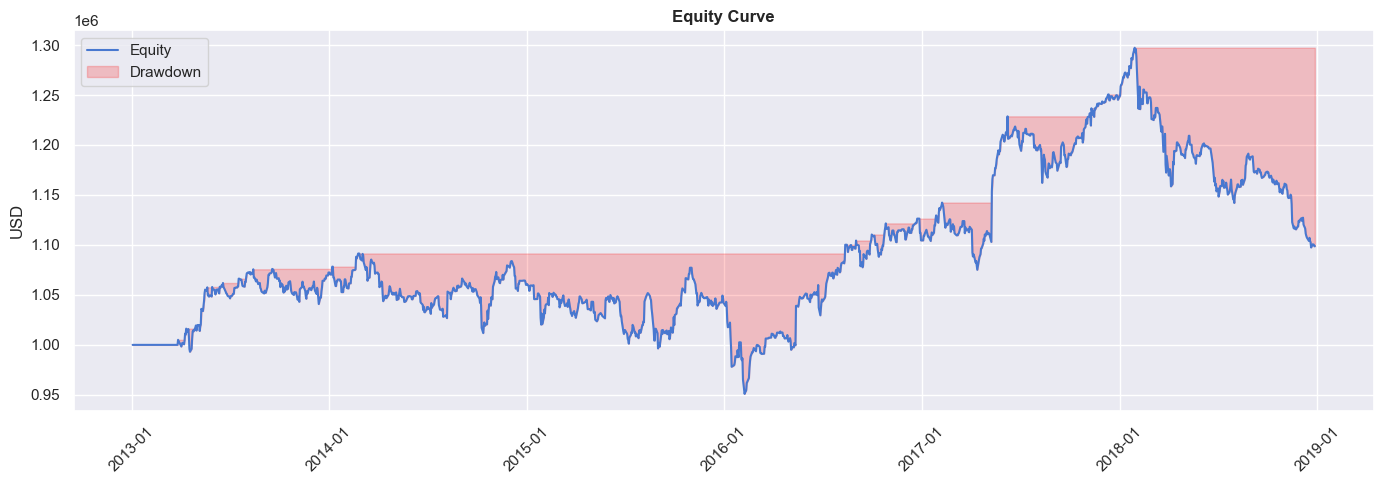

In [6]:
if weight_vectors.size > 0:
    # Generate signals for each spread
    signals_per_spread = {}
    half_lives = {}
    
    for col in spreads.columns:
        z = features.compute_zscore(spreads[col])
        bands = features.zscore_percentile_bands(spreads[col])
        sig = models.generate_signals(z, zscore_percentiles=bands)
        signals_per_spread[col] = sig
        half_lives[col] = features.ou_half_life(spreads[col])
    
    # Run backtest
    bt_result = backtest.run_backtest(
        prices,
        weight_vectors,
        signals_per_spread,
        initial_capital=config.INITIAL_CAPITAL,
        position_size=config.POSITION_SIZE,
        stop_loss=config.STOP_LOSS,
        max_exposure=config.MAX_EXPOSURE,
        drawdown_limit=config.DRAWDOWN_LIMIT,
        transaction_cost_bps=config.TRANSACTION_COST_BPS,
        short_borrow_rate=config.SHORT_BORROW_RATE,
        max_half_life_hold=config.MAX_HALF_LIFE_HOLD,
        half_lives=half_lives,
    )
    
    print(f'Final Equity: ${bt_result["final_equity"]:,.2f}')
    print(f'Return: {(bt_result["final_equity"] / config.INITIAL_CAPITAL - 1) * 100:.2f}%')
    print(f'Trades: {len(bt_result["trades"])}')
    
    # Equity curve
    fig, ax = plt.subplots(figsize=(14, 5))
    utils.plot_equity_curve(bt_result['equity_curve'], ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print('No cointegration — skipping backtest.')

---
## 7. Walk-Forward Analysis
Rolling train/test with Train vs. Test comparison.

In [7]:
# Walk-forward backtest
wf_result = backtest.walk_forward_backtest(
    prices,
    train_window=config.WF_TRAIN_WINDOW,
    test_window=config.WF_TEST_WINDOW,
)

print(f'Walk-Forward Results:')
print(f'  Total Folds: {wf_result["n_folds"]}')
print(f'  Valid Folds: {wf_result["n_valid_folds"]}')
print(f'  Skipped (Rank 0): {wf_result["n_skipped"]}')

# Plot OOS equity curve
if not wf_result['oos_equity_curve'].empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    utils.plot_equity_curve(wf_result['oos_equity_curve'], ax=ax)
    ax.set_title('Walk-Forward OOS Equity Curve', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Fold summary
fold_summary = []
for f in wf_result['fold_results']:
    if 'equity_curve' in f:
        ret = f['returns']
        fold_summary.append({
            'Fold': f['fold'],
            'Rank': f.get('rank', 0),
            'Sharpe': utils.net_sharpe_ratio(ret),
            'Max DD': utils.max_drawdown(f['equity_curve']),
            'Final $': f['final_equity'],
        })
    else:
        fold_summary.append({
            'Fold': f['fold'],
            'Rank': 0,
            'Sharpe': np.nan,
            'Max DD': np.nan,
            'Final $': np.nan,
        })

fold_df = pd.DataFrame(fold_summary)
display(fold_df)

Walk-Forward Results:
  Total Folds: 15
  Valid Folds: 0
  Skipped (Rank 0): 15


,Fold,Rank,Sharpe,Max DD,Final $
0,0,0,NaN,NaN,NaN
1,1,0,NaN,NaN,NaN
2,2,0,NaN,NaN,NaN
3,3,0,NaN,NaN,NaN
4,4,0,NaN,NaN,NaN
5,5,0,NaN,NaN,NaN
6,6,0,NaN,NaN,NaN
7,7,0,NaN,NaN,NaN
8,8,0,NaN,NaN,NaN
9,9,0,NaN,NaN,NaN


---
## 8. Essential Dashboard
7 scalar metrics + 6 time-varying plots.

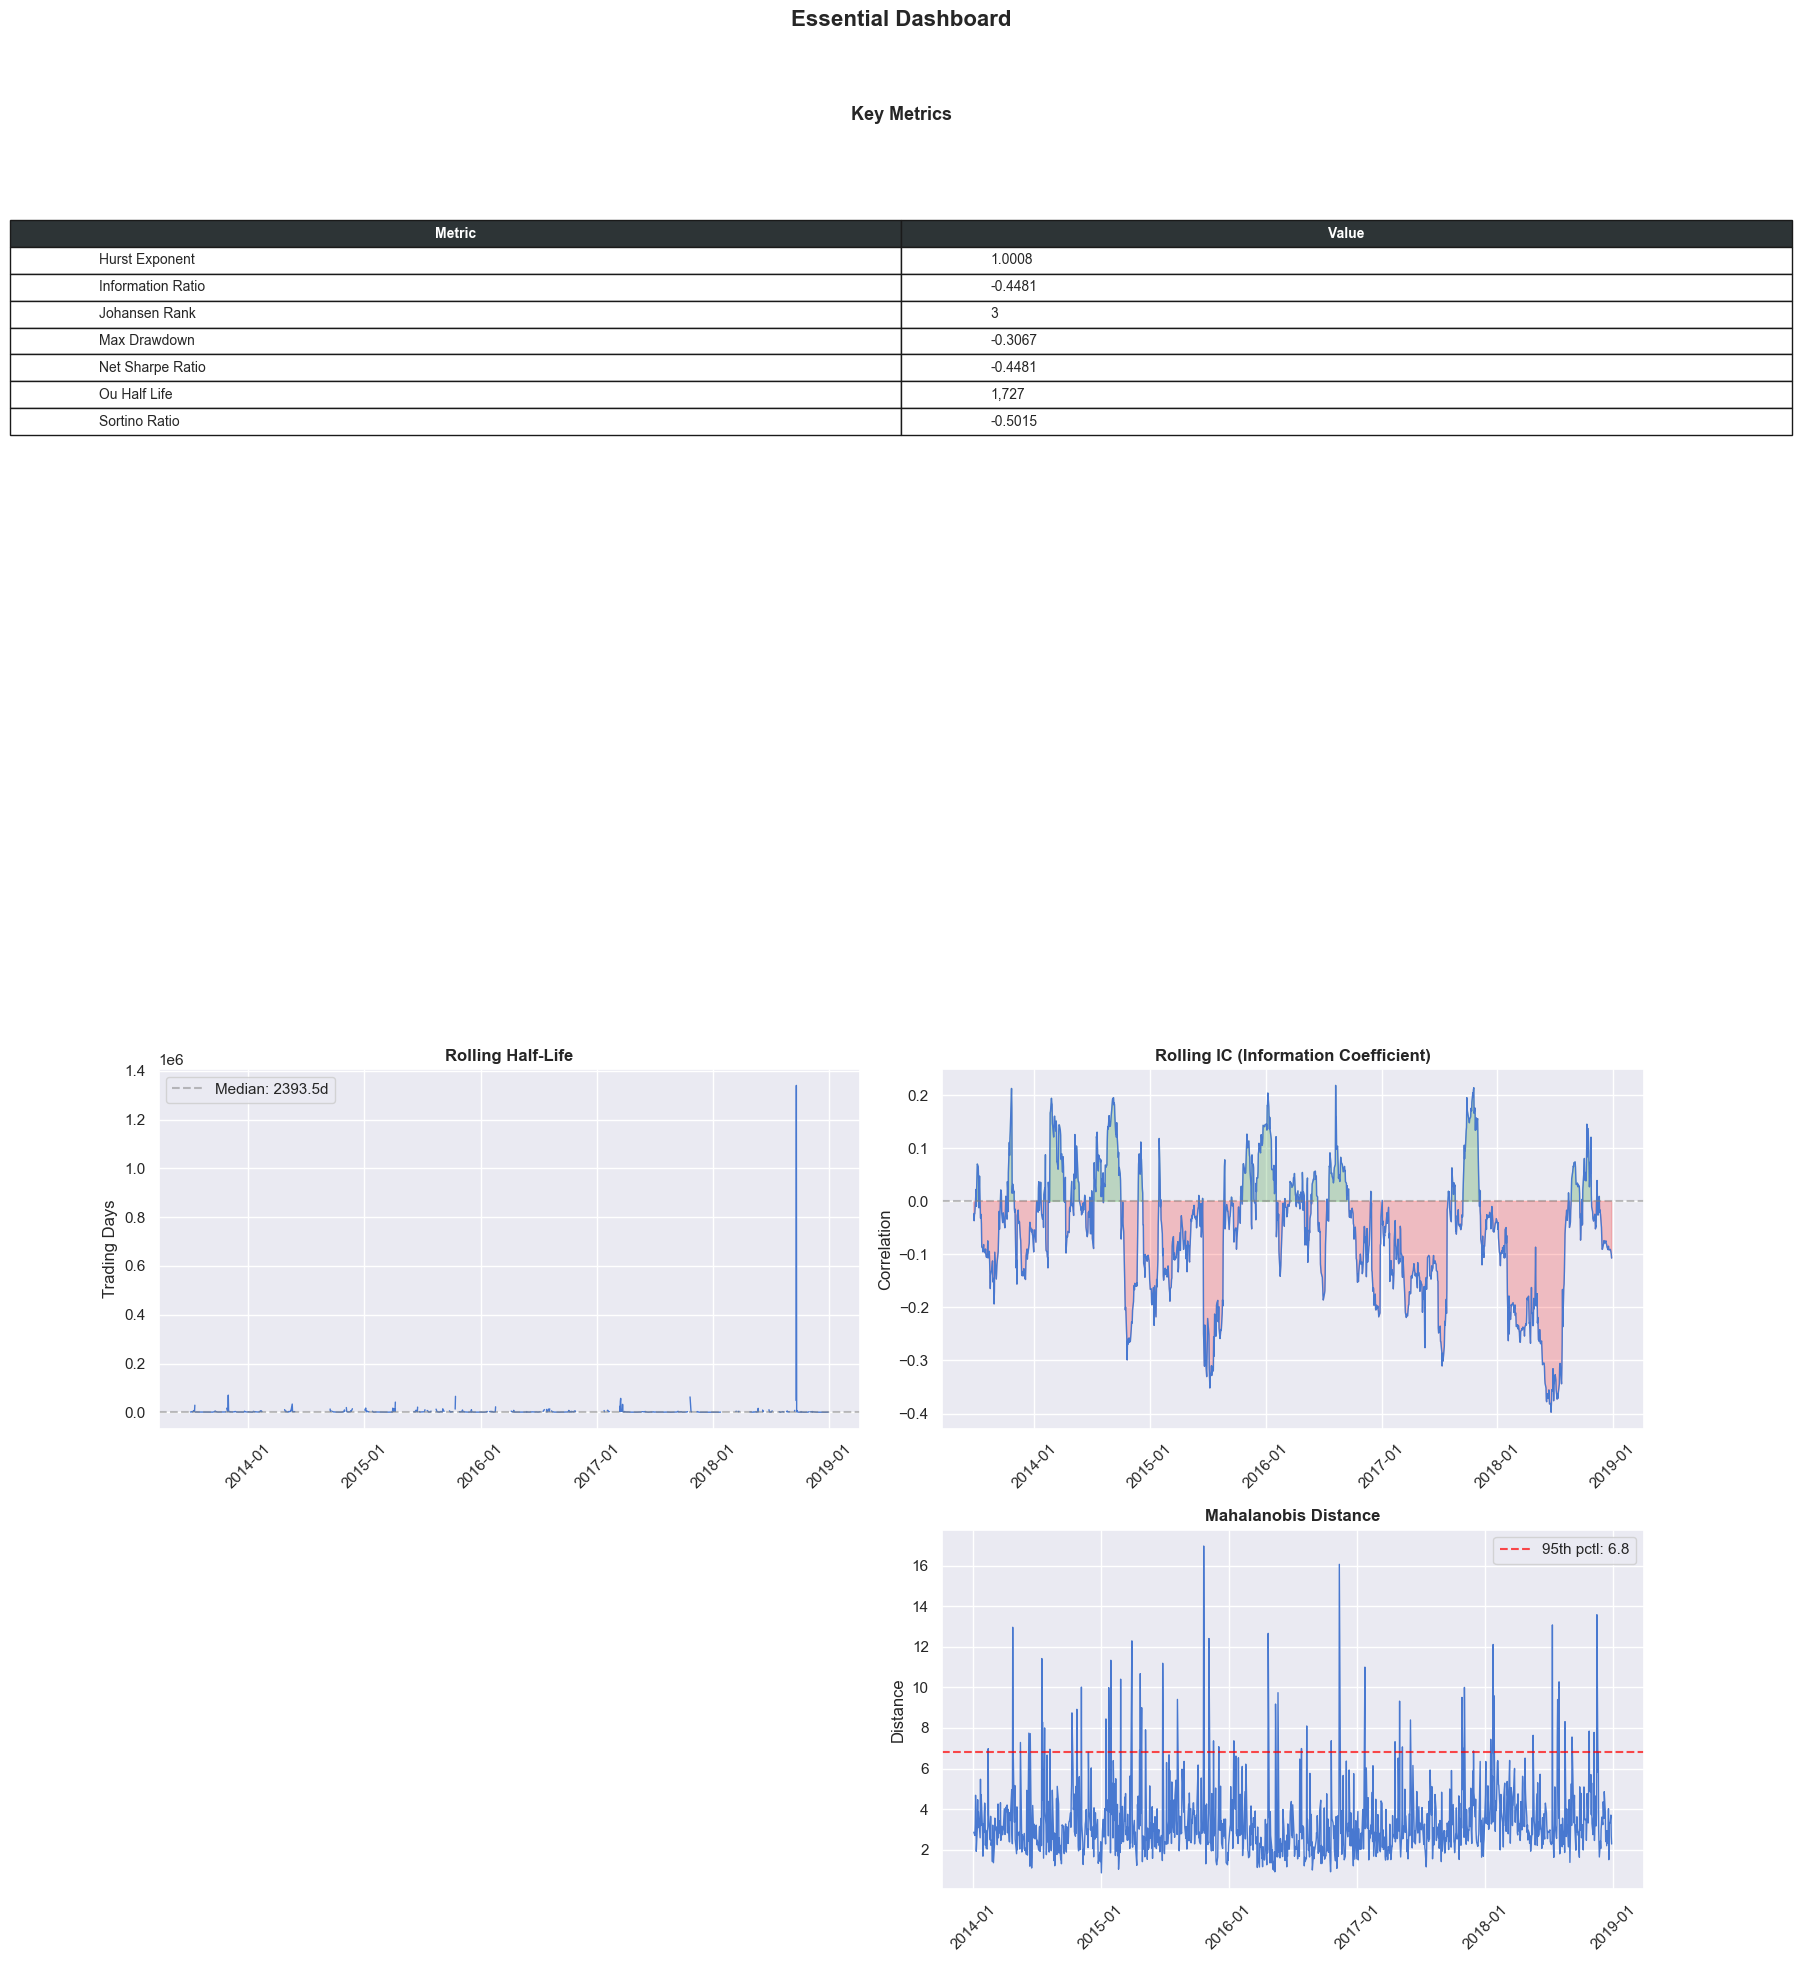

In [8]:
if weight_vectors.size > 0:
    # Compute all metrics
    all_metrics = utils.compute_all_metrics(
        equity_curve=bt_result['equity_curve'],
        returns=bt_result['returns'],
        spread=spread_1,
        zscore=zscore_1,
        asset_returns=returns,
        johansen_rank_val=rank,
    )
    
    dashboard.build_essential_dashboard(all_metrics)
else:
    print('No data for dashboard.')

---
## 9. Full Dashboard
All 28 metrics + 13 time-varying plots + eigenportfolio weights.

In [ ]:
if weight_vectors.size > 0:
    # Add additional time-varying metrics
    all_metrics['pca_persistence'] = features.pca_persistence(returns)
    all_metrics['condition_number'] = features.covariance_condition_number(returns)
    all_metrics['copula_concordance'] = features.copula_concordance(returns)
    
    # Z-score specific
    all_metrics['zscore_bands'] = bands_1
    all_metrics['zscore_decay'] = features.zscore_decay_rate(zscore_1)
    all_metrics['mean_crossing_count'] = features.mean_crossing_count(spread_1)
    all_metrics['crowding_sensitivity'] = utils.crowding_sensitivity(bt_result['returns'])
    
    # Tail dependence
    all_metrics['tail_dependence'] = utils.tail_dependence_series(returns)
    
    dashboard.build_full_dashboard(all_metrics)
    
    # Eigenportfolio weight heatmap
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(weight_df, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax)
    ax.set_title('Eigenportfolio Weights', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No data for full dashboard.')